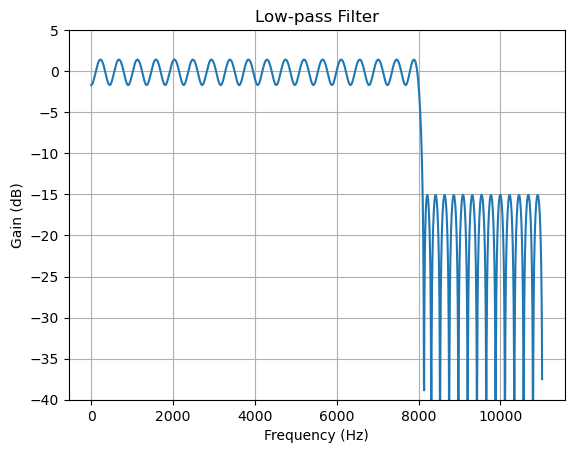

In [16]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

fs = 22050  # Sample rate, Hz


def plot_response(w, h, title):
    "Utility function to plot response functions"
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(w, 20 * np.log10(np.abs(h)))
    ax.set_ylim(-40, 5)
    ax.grid(True)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Gain (dB)")
    ax.set_title(title)


cutoff = 8000.0  # Desired cutoff frequency, Hz
trans_width = 100  # Width of transition from pass to stop, Hz
numtaps = 100  # Size of the FIR filter.
taps = signal.remez(numtaps, [0, cutoff, cutoff + trans_width, 0.5 * fs], [1, 0], fs=fs)
w, h = signal.freqz(taps, [1], worN=2000, fs=fs)
plot_response(w, h, "Low-pass Filter")
plt.show()

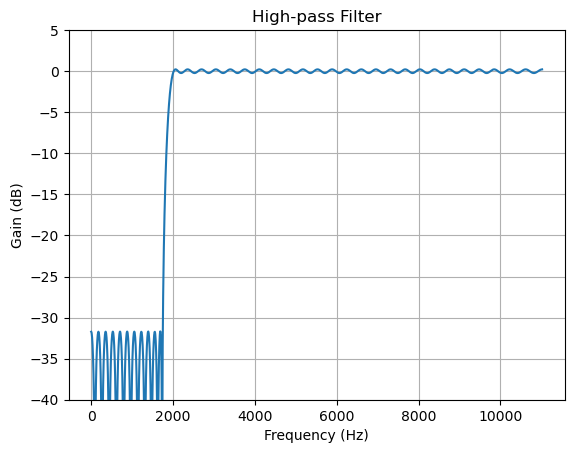

In [2]:
cutoff = 2000.0  # Desired cutoff frequency, Hz
trans_width = 250  # Width of transition from pass to stop, Hz
numtaps = 125  # Size of the FIR filter.
taps = signal.remez(numtaps, [0, cutoff - trans_width, cutoff, 0.5 * fs], [0, 1], fs=fs)
w, h = signal.freqz(taps, [1], worN=2000, fs=fs)
plot_response(w, h, "High-pass Filter")
plt.show()

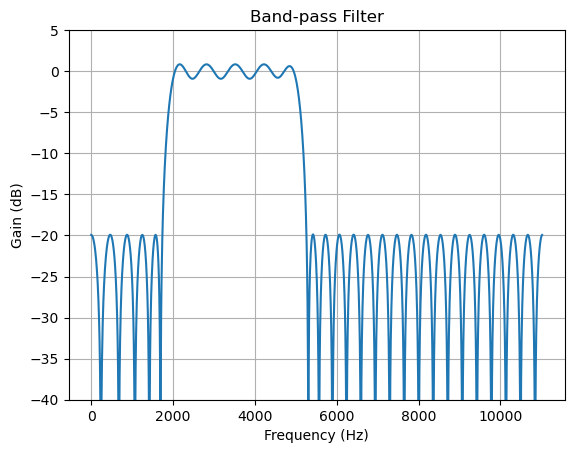

In [3]:
band = [2000, 5000]  # Desired pass band, Hz
trans_width = 260  # Width of transition from pass to stop, Hz
numtaps = 63  # Size of the FIR filter.
edges = [0, band[0] - trans_width, band[0], band[1], band[1] + trans_width, 0.5 * fs]
taps = signal.remez(numtaps, edges, [0, 1, 0], fs=fs)
w, h = signal.freqz(taps, [1], worN=2000, fs=fs)
plot_response(w, h, "Band-pass Filter")
plt.show()

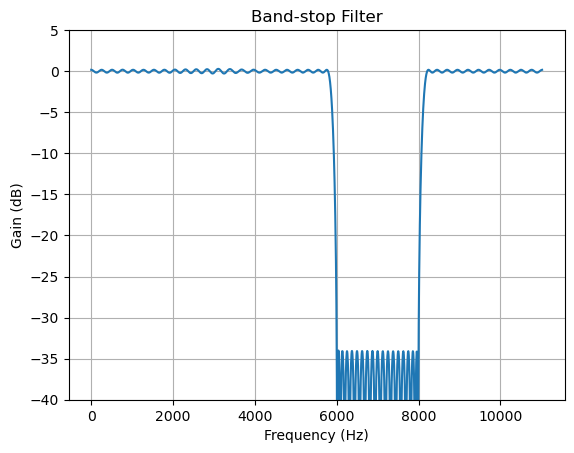

In [4]:
band = [6000, 8000]  # Desired stop band, Hz
trans_width = 200  # Width of transition from pass to stop, Hz
numtaps = 175  # Size of the FIR filter.
edges = [0, band[0] - trans_width, band[0], band[1], band[1] + trans_width, 0.5 * fs]
taps = signal.remez(numtaps, edges, [1, 0, 1], fs=fs)
w, h = signal.freqz(taps, [1], worN=2000, fs=fs)
plot_response(w, h, "Band-stop Filter")
plt.show()